# Simulation of the article *Nonlinear decision-making with enzymatic neural networks*, Nature 2022, from Okumura, Gines, Lobato-Dauzier, Baccouche, Deteix, Fujii, Rondelez, and Genot

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
code_dir = os.path.expanduser("~/Documents/PLR1/pen-dna-simulator/")
sys.path.append(code_dir)


from PEN_simulation import *

## 1) Linear Classifiers

In [32]:
def linear_classifier(temperature=45, 
                      BsmI_conc=400,
                      NBI_conc=0,
                      pol_conc=40,
                      exo_conc=3,
                      leak=0,
                      X1_conc=0, 
                      X2_conc=0, 
                      alpha_conc=0, 
                      f_conc=0, 
                      drain_f_conc=0, 
                      drain_alpha_conc=0, 
                      aT_alpha_conc=0, 
                      cT_X1_alpha_conc=0, 
                      cT_X2_alpha_conc=0, 
                      cT_X1_dTalpha_conc=0, 
                      cT_X1_dtf_conc=0, 
                      cT_X1_f_conc=0, 
                      cT_X2_f_conc=0, 
                      rT_conc=0):
    """Create a system with a signal and a drain"""
    system = PEN_System(temperature=temperature)
    system.leak = leak
    system.concentration_BsmI=BsmI_conc
    system.concentration_NBI=NBI_conc
    system.concentration_pol= pol_conc / 5 # arbitrary adjustment for using vent instead of Bst
    system.concentration_exo= exo_conc

    # Create a signal
    X1 = Signal(name="X1", sequence="AGGCAAGATGCTGGCATAGCTGT", concentration=X1_conc, protected=False, IsDrained=False)
    X2 = Signal(name="X2", sequence="TAGCTTATCAGACTGATGTTGA", concentration=X2_conc, protected=False, IsDrained=False)
    alpha = Signal(name="alpha", sequence="CATTCTGGACTG", concentration=alpha_conc, protected=False, IsDrained=True)
    f = Signal(name="f", sequence="CATTCGTACAGA", concentration=f_conc, protected=False, IsDrained=False)


    system.add_signal(X1)
    system.add_signal(X2)
    system.add_signal(alpha)
    system.add_signal(f)

    # Create a drain
    drain_f = Drain(name="drain", input=alpha, concentration=drain_f_conc, sequence="TTTTTCAGTCCAGAATG", protected=True) # Weird name but according to the article
    drain_alpha = Drain(name="drain_f", input=alpha, concentration=drain_alpha_conc, sequence="TTCAGTCCAGAATG", protected=True)
    drain_alpha_prod = Drain(name="drain_prod", input=alpha, concentration=0, sequence="TTCAGTCCAGAATG", protected=False)

    system.add_drain(drain_alpha)
    system.add_drain(drain_alpha_prod)
    system.add_drain(drain_f)
    
    # Create a template
    aT_alpha = Template(name="aT_alpha", sequence='CAGTCCAGAATGCAGTCCAGAA', input=alpha, output=alpha, concentration=aT_alpha_conc, nick="BsmI", protected=True, irreversible=False, phosphated=True)
    cT_X1_alpha = Template(name="cT_X1_alpha", sequence='CAGTCCAGAATGCAAACAGCTATGCCAGCA', input=X1, output=alpha, concentration=cT_X1_alpha_conc, nick="BsmI", protected=True, irreversible=False)
    cT_X2_alpha = Template(name="cT_X2_alpha", sequence='CAGTCCAGAATGCAATCAACATCAGTCTGAT', input=X2, output=alpha, concentration=cT_X2_alpha_conc, nick="BsmI", protected=True, irreversible=False)
    cT_X1_dTalpha = Template(name="cT_X1_dTalpha", sequence='CATTCTGGACTGTTCAATGACTCACAGCTATGCCAGCA', input=X1, output=drain_alpha_prod, concentration=cT_X1_dTalpha_conc, nick="NBI", protected=True, irreversible=True)
    cT_X1_dtf = Template(name="cT_X1_df", sequence='CATTCTGGACTGTTTTTCAATGACTCACAGCTATGCCAGCA', input=X1, output=drain_f, concentration=cT_X1_dtf_conc, nick="NBI", protected=True, irreversible=True)
    cT_X1_f = Template(name="cT_X1_f", sequence='TCTGTACGAATGCAAACAGCTATGCCAGCA', input=X1, output=f, concentration=cT_X1_f_conc, nick="BsmI", protected=True, irreversible=False)
    cT_X2_f = Template(name="cT_X2_f", sequence='TCTGTACGAATGCAATCAACATCAGTCTGAT', input=X2, output=f, concentration=cT_X2_f_conc, nick="BsmI", protected=True, irreversible=False)


    # Create a Reporter
    rT_output = Signal(name="rT_output", sequence="CATTCAGAAT", concentration=0, protected=False, IsDrained=False)
    system.add_signal(rT_output)
    rT_alpha = Reporter(name="rT_alpha", input=alpha, fluorophore="FAM", quencher="BHQ1", sequence="ATTCTGAATGCAGTCCAGAAT", concentration=rT_conc, reversible=True, output=rT_output)
    system.add_reporter(rT_alpha)


    system.add_template(aT_alpha)
    system.add_template(cT_X1_alpha)
    system.add_template(cT_X2_alpha)
    system.add_template(cT_X1_dTalpha)
    system.add_template(cT_X1_dtf)
    system.add_template(cT_X1_f)
    system.add_template(cT_X2_f)
    
    return system

### Fig.1f left Weight adjust.

KeyboardInterrupt: 

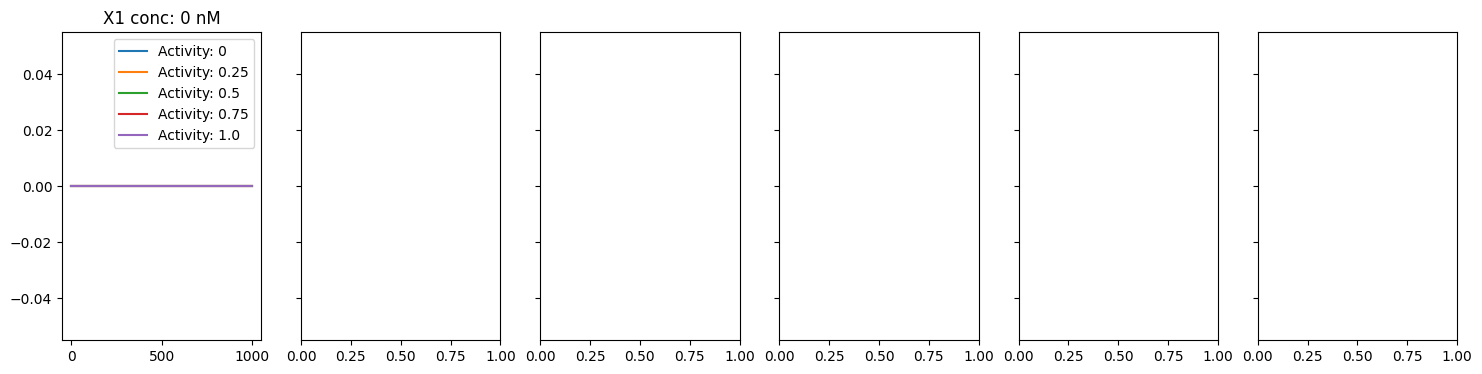

In [3]:
t = np.linspace(0, 1000, 1001) #1000 minutes

X1_concs = [0, 0.6, 1.3, 2.5, 5, 10]
weight_activity = [0, 0.25, 0.5, 0.75, 1.0]

# Create a figure with subplots in a row
fig, axes = plt.subplots(1, len(X1_concs), figsize=(18, 4), sharey=True)

for i, conc in enumerate(X1_concs):
    results = []
    for activity in weight_activity:
        system = linear_classifier(
            temperature=45,
            X1_conc=conc,
            cT_X1_alpha_conc=10*activity,
            cT_X1_f_conc=10*(1-activity),
            rT_conc=25,
        )
        y = system.solve_system(t)
        fluo = system.fluorescence_list(y, "rT_alpha")
        results.append(fluo)

    for fluo, activity in zip(results, weight_activity):
        axes[i].plot(t, fluo, label=f'Activity: {activity}')


    axes[i].set_title(f'X1 conc: {conc} nM')
    axes[i].legend()

plt.tight_layout()
plt.show()


It seems that we get the proper behavior, but we need to implement the rT, and find the proper polymerase activity (here vent instead of Bst)

### Fig.1f middle Summation

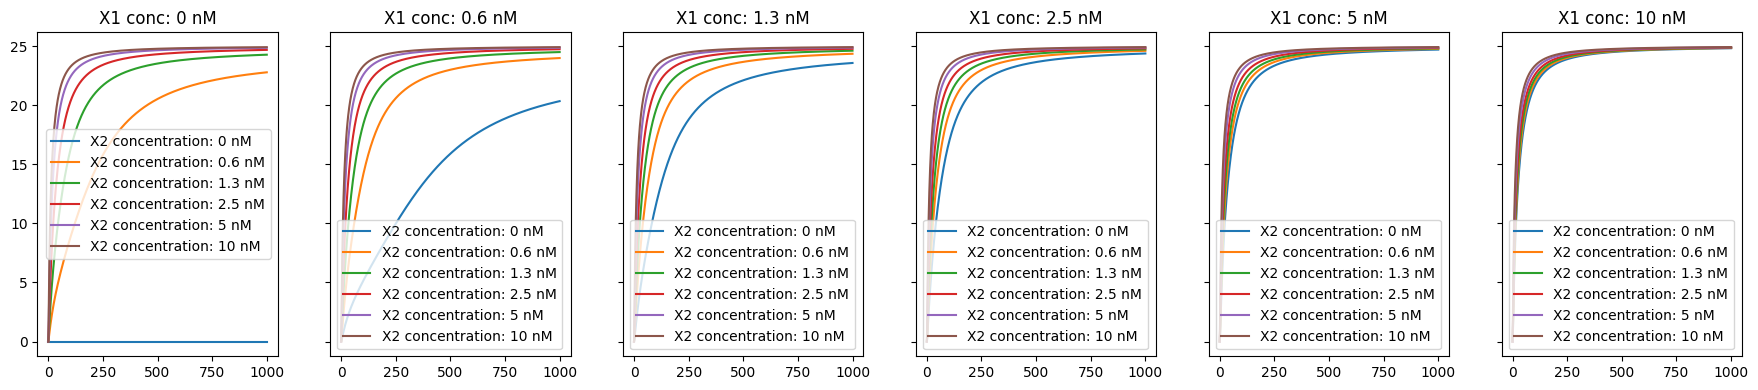

In [ ]:
t = np.linspace(0, 1000, 1001) #1000 minutes

X_concs = [0, 0.6, 1.3, 2.5, 5, 10]

# Create a figure with subplots in a row
fig, axes = plt.subplots(1, len(X_concs), figsize=(18, 4), sharey=True)

for i, X1_conc in enumerate(X_concs):
    results = []
    for X2_conc in X_concs:
        system = linear_classifier(
            temperature=45,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
            cT_X1_alpha_conc=5,
            cT_X1_f_conc=5,
            cT_X2_alpha_conc=10,
            rT_conc=25,
        )

        y = system.solve_system(t)
        fluo = system.fluorescence_list(y, "rT_alpha")
        results.append(fluo)

    for fluo, x_conc in zip(results, X_concs):
        axes[i].plot(t, fluo, label=f'X2 concentration: {x_conc} nM')

    axes[i].set_title(f'X1 conc: {X1_conc} nM')
    axes[i].legend()

plt.tight_layout()
plt.show()


### Fig.1f right Activation f.

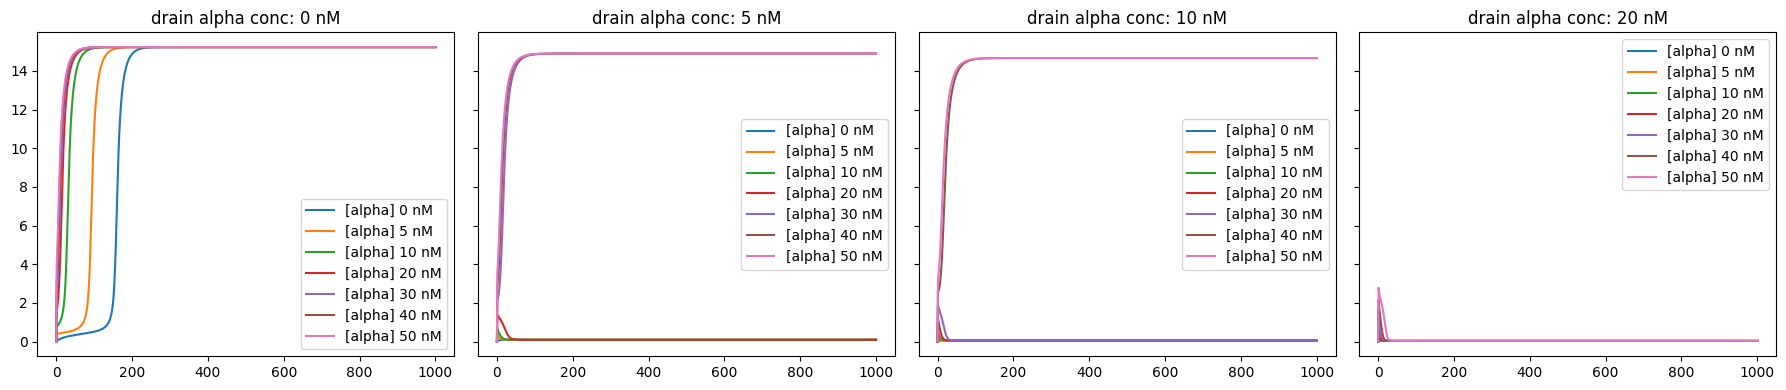

In [ ]:
t = np.linspace(0, 1000, 1001) #1000 minutes

alpha_concs = [0, 5, 10, 20, 30, 40, 50]

# dT_conc =     [0, 5, 10, 20, 30, 50]
dT_conc =     [0, 5,10, 20]

# Create a figure with subplots in a row
fig, axes = plt.subplots(1, len(dT_conc), figsize=(18, 4), sharey=True)

for i, dT_conc in enumerate(dT_conc):
    results = []
    for alpha_conc in alpha_concs:
        system = linear_classifier(
            temperature=45,
            leak=2e-5,
            BsmI_conc=400,
            pol_conc=50,
            exo_conc=23,
            aT_alpha_conc=30,
            drain_alpha_conc=dT_conc,
            rT_conc=25,
            alpha_conc=alpha_conc,
        )

        y = system.solve_system(t)
        fluo = system.fluorescence_list(y, "rT_alpha")
        results.append(fluo)

    for fluo, alpha_c in zip(results, alpha_concs):
        axes[i].plot(t, fluo, label=f'[alpha] {alpha_c} nM')

    axes[i].set_title(f'drain alpha conc: {dT_conc} nM')
    axes[i].legend()

plt.tight_layout()
plt.show()


We don't have exactly the same results, but the same behaviour. This is maybe due the protection of the drain templates, making them quicker to uNBInd from.

Drain templates simulation are explored in the notebook of Montagne2016, *Boosting similarity...*

### Fig.2a Positive Bulk

[0.         0.16666667 0.33333333 0.5        0.66666667 0.83333333
 1.        ]


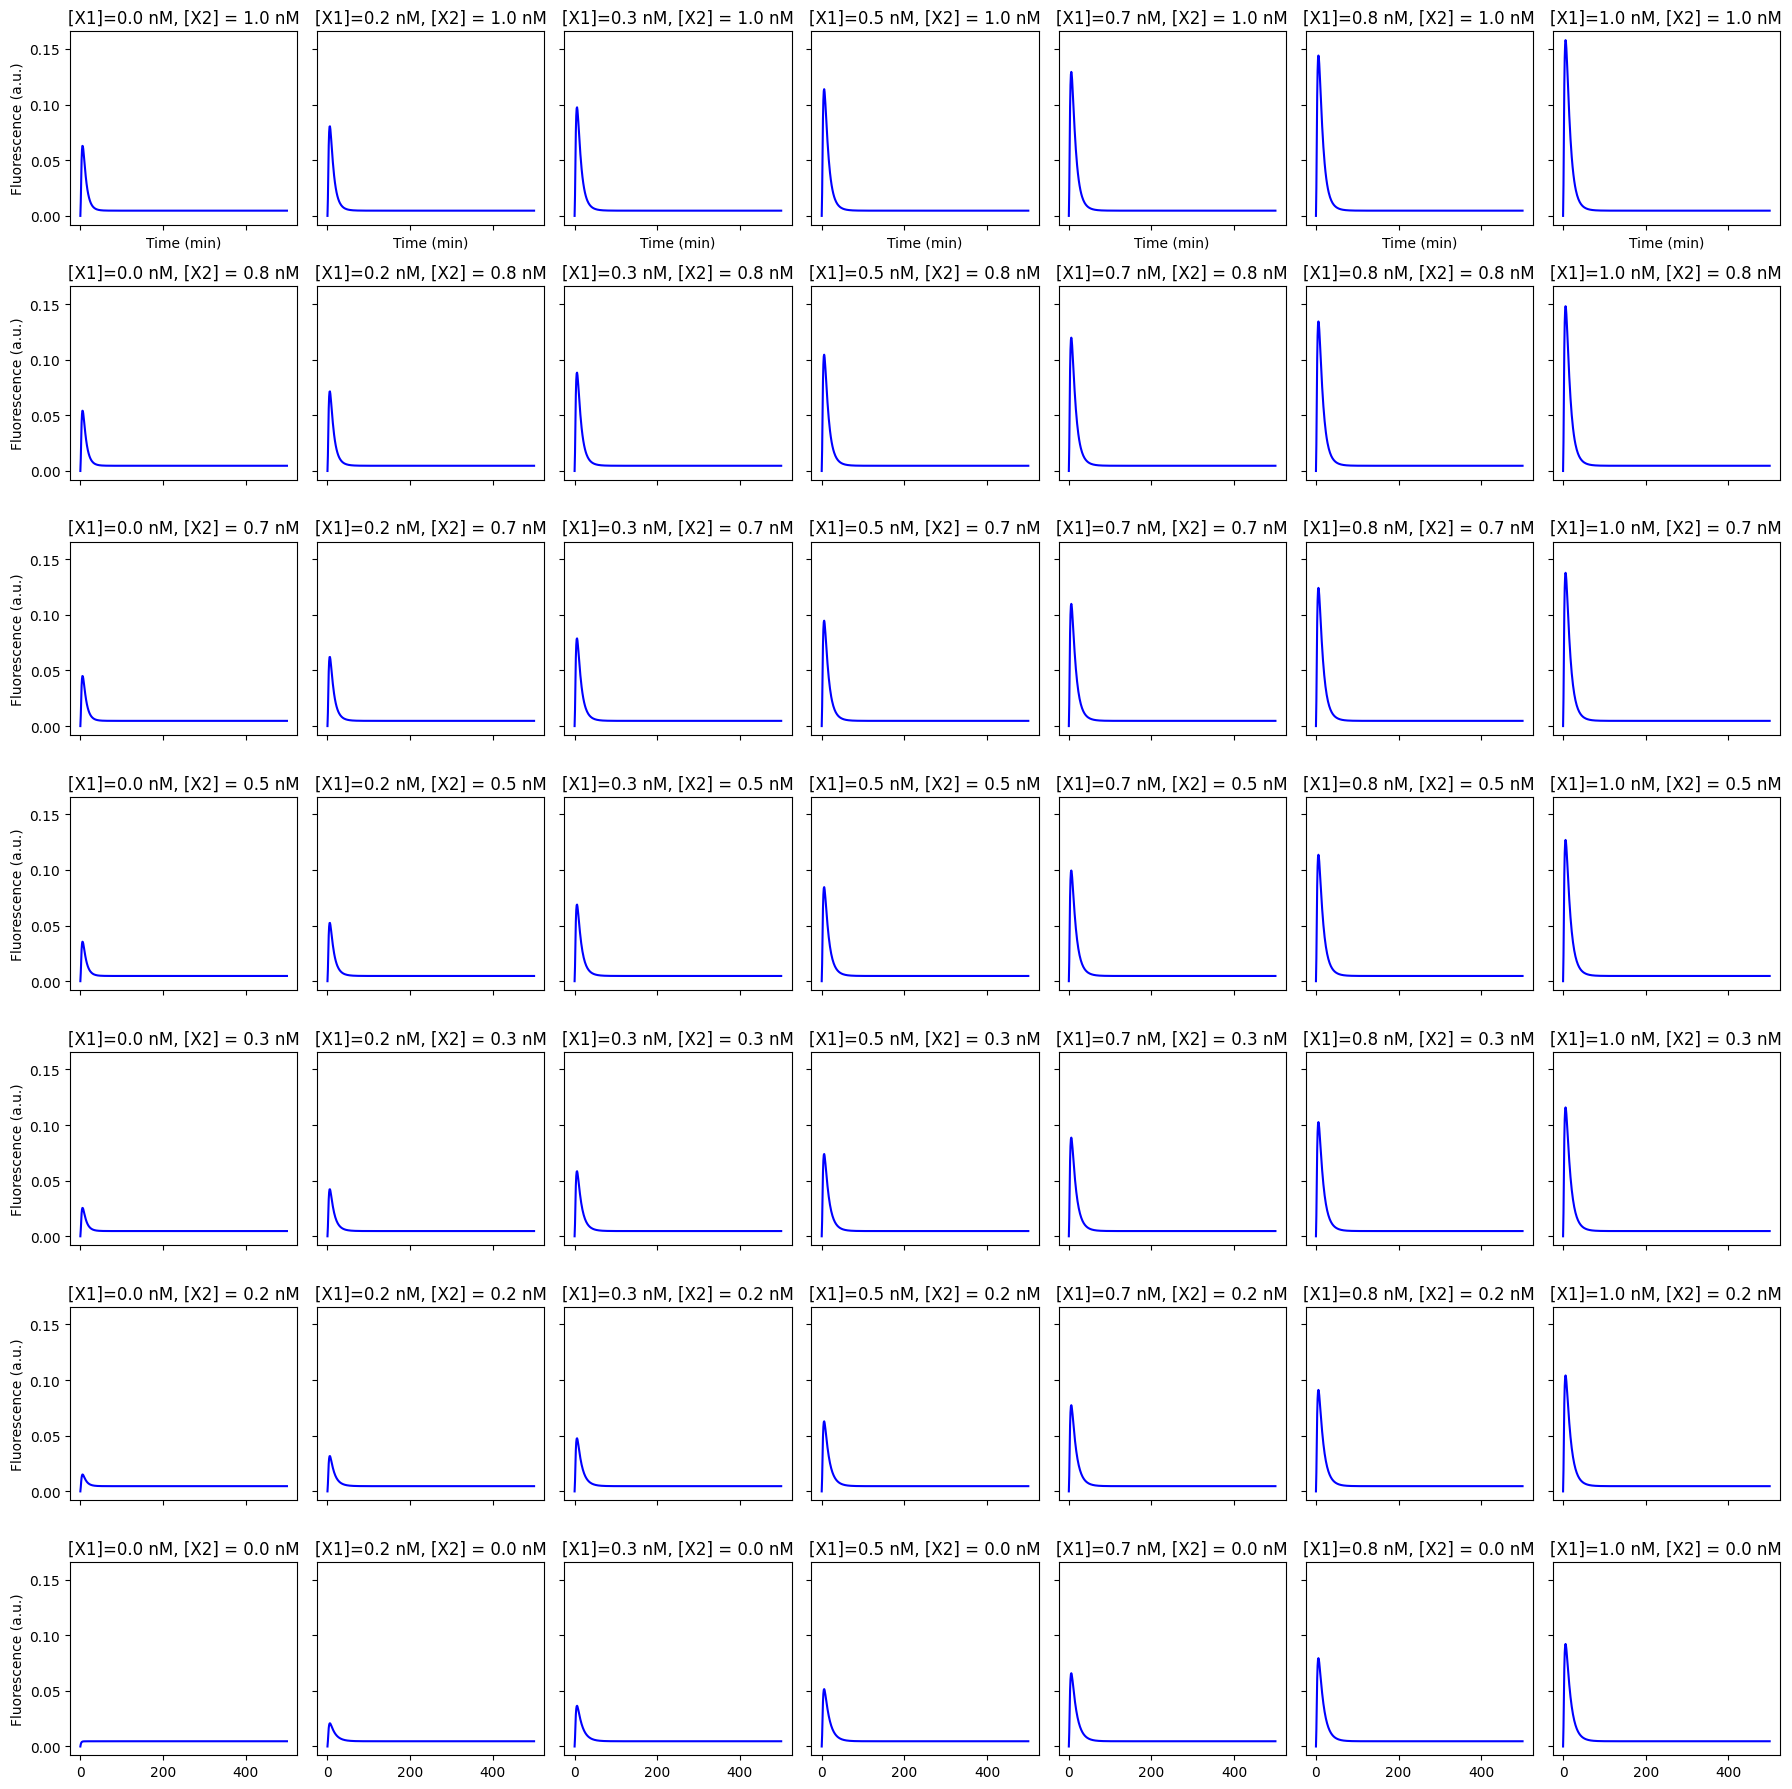

In [86]:
t= np.linspace(0, 500, 501) #500 minutes

X_concs=np.linspace(0,1,7)
# X_concs=[0.25,0.5,0.75,1]
# times 10
# X_concs=np.multiply(X_concs,10)
print(X_concs)

fig, axes = plt.subplots(len(X_concs), len(X_concs), figsize=(18, 18), sharey=True, sharex=True)

for i, X2_conc in enumerate(X_concs[::-1]):
    
    for j, X1_conc in enumerate(X_concs):
        system = linear_classifier(
            temperature=45,
            pol_conc=30, # Adjustment for Vent, hard to find the right value
            exo_conc=23,
            BsmI_conc=400,
            aT_alpha_conc=30,
            leak=6e-6, # Seems good
            drain_alpha_conc=30, 
            rT_conc=25,
            cT_X1_alpha_conc=1,
            cT_X2_alpha_conc=1,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )
        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")

        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='blue')
        else:
            axes[i,j].plot(t, fluo, color='green')
        axes[i,j].set_title(f'[X1]={X1_conc:.1f} nM, [X2] = {X2_conc:.1f} nM')

        if i==0:
            axes[i,j].set_xlabel('Time (min)')
        if j==0:
            axes[i,j].set_ylabel('Fluorescence (a.u.)')

plt.tight_layout()
plt.show()




We simulated the same behaviour, however we got a order 1 difference with the experiment...

### Fig.2b Negative Bulk

[0.   0.25 0.5  0.75 1.  ]
[0.   0.25 0.5  0.75 1.  ]
0.0 1.0
0.00, 1.00 : on
0.25 1.0
0.25, 1.00 : on
0.5 1.0
0.50, 1.00 : on
0.75 1.0
0.75, 1.00 : on
1.0 1.0
1.00, 1.00 : on
0.0 0.75
0.00, 0.75 : on
0.25 0.75
0.25, 0.75 : on
0.5 0.75
0.50, 0.75 : on
0.75 0.75
0.75, 0.75 : on
1.0 0.75
1.00, 0.75 : on
0.0 0.5
0.00, 0.50 : on
0.25 0.5
0.25, 0.50 : on
0.5 0.5
0.50, 0.50 : on
0.75 0.5
0.75, 0.50 : on
1.0 0.5
1.00, 0.50 : on
0.0 0.25
0.00, 0.25 : on
0.25 0.25
0.25, 0.25 : on
0.5 0.25
0.50, 0.25 : on
0.75 0.25
0.75, 0.25 : on
1.0 0.25
1.00, 0.25 : off
0.0 0.0
0.00, 0.00 : off
0.25 0.0
0.25, 0.00 : off
0.5 0.0
0.50, 0.00 : off
0.75 0.0
0.75, 0.00 : off
1.0 0.0
1.00, 0.00 : off


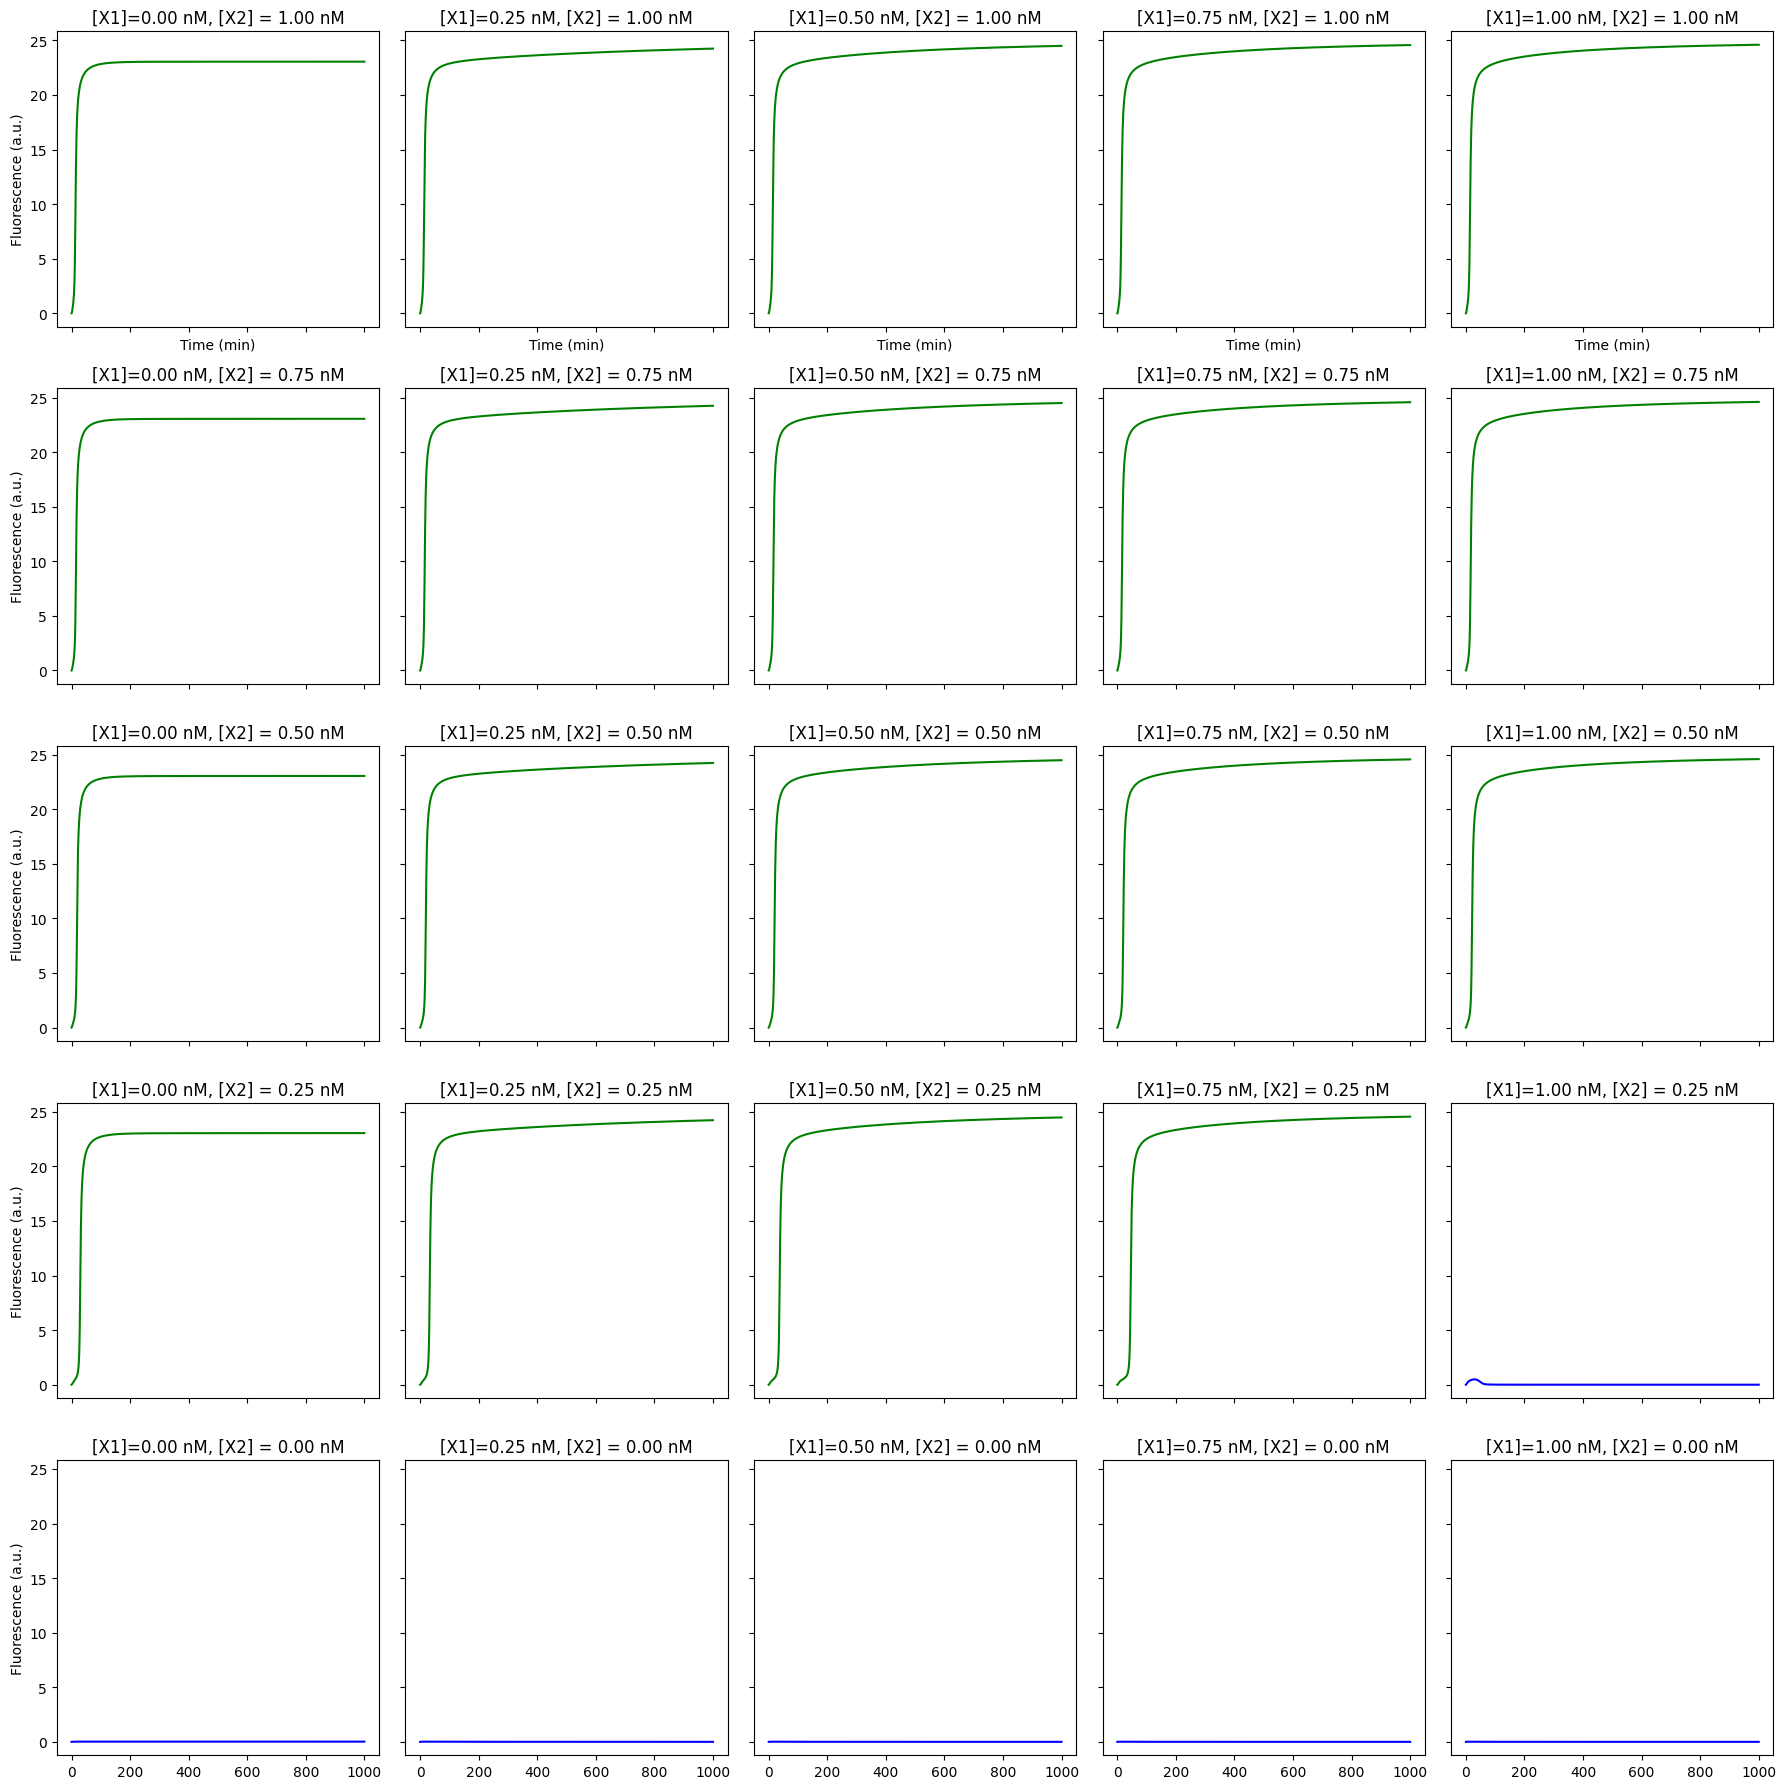

In [75]:
t= np.linspace(0, 1000, 1001) #1000 minutes

X1_concs=np.linspace(0,1,5)
X2_concs=np.linspace(0,1,5)
# X_concs=[0.25,0.5,0.75,1]
# times 10
# X1_concs=np.multiply(X1_concs,10)
# X2_concs=np.multiply(X2_concs,10)
print(X1_concs)
print(X2_concs)

fig, axes = plt.subplots(len(X2_concs), len(X1_concs), figsize=(18, 18), sharey=True, sharex=True)

for i, X2_conc in enumerate(X2_concs[::-1]):
# for i, X2_conc in enumerate(X2_concs):
    
    for j, X1_conc in enumerate(X1_concs):
        print(X1_conc, X2_conc)
        system = linear_classifier(
            temperature=45,
            pol_conc=30 *4, # Adjustment for Vent, hard to find the right value
            exo_conc=23,
            BsmI_conc=400,
            NBI_conc=10,
            aT_alpha_conc=30,
            leak=1e-6, # Seems good
            drain_alpha_conc=5, 
            rT_conc=25,
            cT_X1_dTalpha_conc=0.6,
            cT_X1_dtf_conc=0.4,
            cT_X2_alpha_conc=1,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )
        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")

        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='blue')
            print(f"{X1_conc:.2f}, {X2_conc:.2f} : off")
        else:
            axes[i,j].plot(t, fluo, color='green')
            print(f"{X1_conc:.2f}, {X2_conc:.2f} : on")
        axes[i,j].set_title(f'[X1]={X1_conc:.2f} nM, [X2] = {X2_conc:.2f} nM')

        if i==0:
            axes[i,j].set_xlabel('Time (min)')
        if j==0:
            axes[i,j].set_ylabel('Fluorescence (a.u.)')

        system.unmalloc()

plt.tight_layout()
plt.show()




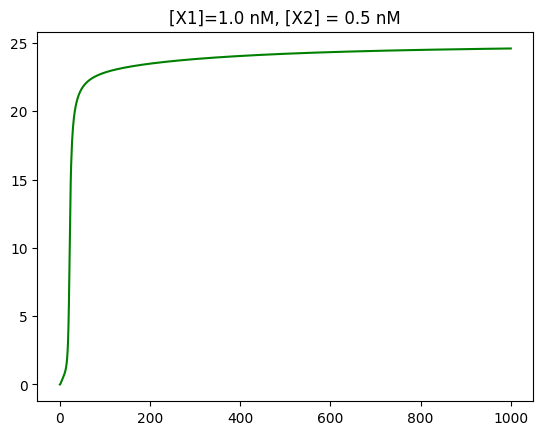

In [82]:
X1_conc=1
X2_conc=0.5

t= np.linspace(0, 1000, 1001) #1000 minutes

system = linear_classifier(
            temperature=45,
            pol_conc=30 *4, # Adjustment for Vent, hard to find the right value
            exo_conc=23,
            BsmI_conc=400,
            NBI_conc=10,
            aT_alpha_conc=30,
            leak=0.1e-6, # Seems good
            drain_alpha_conc=5, 
            rT_conc=25,
            cT_X1_dTalpha_conc=0.6,
            cT_X1_dtf_conc=0.4,
            cT_X2_alpha_conc=1,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )
y=system.solve_system(t)
fluo=system.fluorescence_list(y, "rT_alpha")
alpha_conc_list=system.concentration_list(y,"alpha", "drained")
drain_list=system.concentration_list(y,"drain_prod", "alone")
drain_list_in=system.concentration_list(y,"drain_prod", "in")
drain_list_ext=system.concentration_list(y,"drain_prod", "ext")

drain_list1=system.concentration_list(y,"drain_f", "alone")
drain_list_in1=system.concentration_list(y,"drain_f", "in")
drain_list_ext1=system.concentration_list(y,"drain_f", "ext")

drain_all=drain_list + drain_list_in + drain_list_ext
drain_all1=drain_list1 + drain_list_in1 + drain_list_ext1

# plt.plot(t,alpha_conc_list)
# plt.plot(t,drain_list, label="alone")
# plt.plot(t,drain_list_in, label="in")
# plt.plot(t,drain_list_ext, label="ext")
# plt.plot(t,drain_all, label="all")

# plt.plot(t,drain_list1, label="alone")
# plt.plot(t,drain_list_in1, label="in")
# plt.plot(t,drain_list_ext1, label="ext")
# plt.plot(t,drain_all1, label="all")


if fluo[-1]<5:
            plt.plot(t, fluo, color='blue')
else:
            plt.plot(t, fluo, color='green')
plt.title(f'[X1]={X1_conc:.1f} nM, [X2] = {X2_conc:.1f} nM')
# plt.legend()

if i==0:
            plt.xlabel('Time (min)')
if j==0:
            plt.ylabel('Fluorescence (a.u.)')

plt.plot()
system.unmalloc()

Again, we get the same behaviour, up to some parameters (drain concentration, polymerase activity)

### Fig.2c Positive droplet 1

[ 0.    1.67  3.33  5.    6.67  8.33 10.  ]


KeyboardInterrupt: 

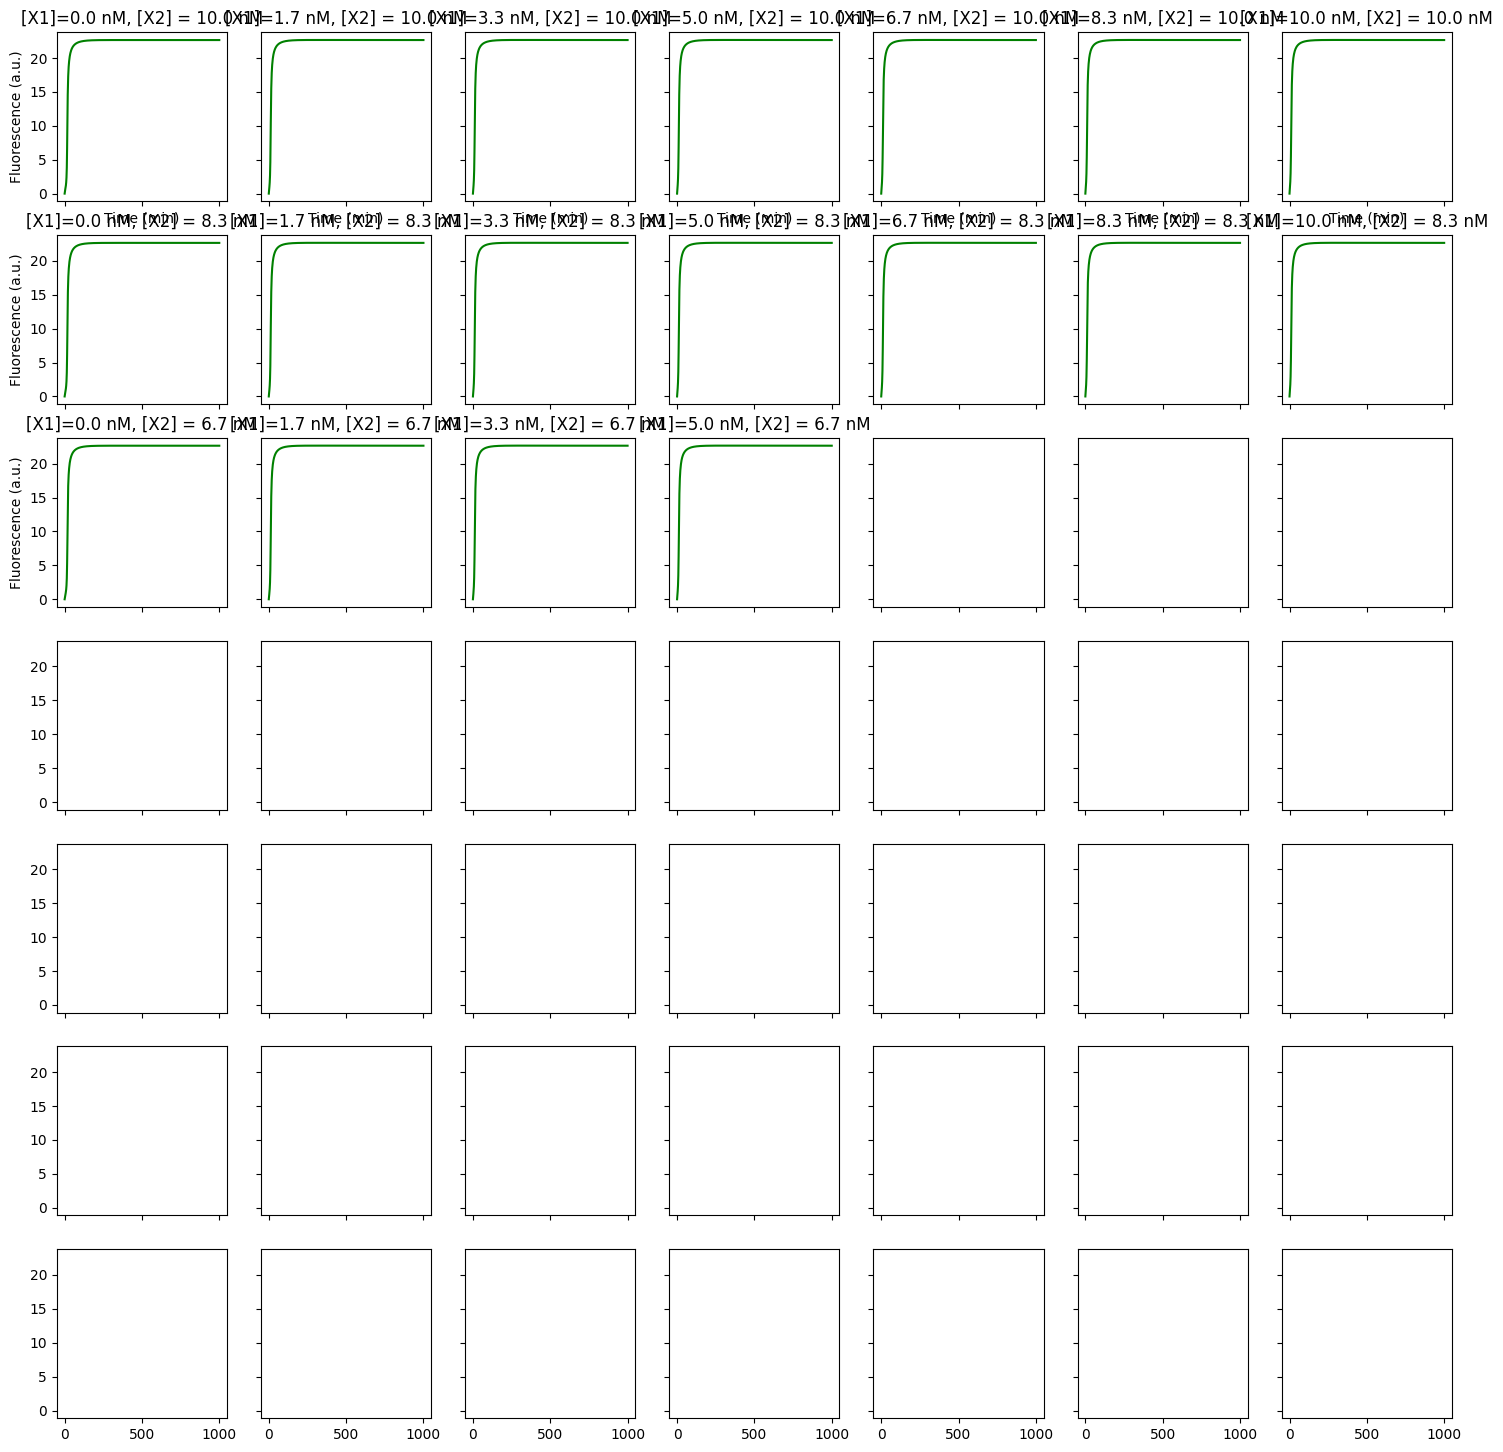

In [ ]:
t= np.linspace(0, 1000, 1001) #1000 minutes

X_concs=[0, 0.167, 0.333, 0.5, 0.667, 0.833, 1]
# X_concs=[0.25,0.5,0.75,1]
# times 10
X_concs=np.multiply(X_concs,10)
print(X_concs)

fig, axes = plt.subplots(len(X_concs), len(X_concs), figsize=(18, 18), sharey=True, sharex=True)

for i, X2_conc in enumerate(X_concs[::-1]):
    
    for j, X1_conc in enumerate(X_concs):
        system = linear_classifier(
            temperature=45,
            pol_conc=30 *4, # Adjustment for Vent, hard to find the right value
            exo_conc=23,
            BsmI_conc=400,
            aT_alpha_conc=30,
            leak=2e-5, # Seems good
            drain_alpha_conc=15, 
            rT_conc=25,
            cT_X1_alpha_conc=0.5,
            cT_X1_f_conc=0.5,
            cT_X2_alpha_conc=0.5,
            cT_X2_f_conc=0.5,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )
        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")

        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='blue')
        else:
            axes[i,j].plot(t, fluo, color='green')
        axes[i,j].set_title(f'[X1]={X1_conc:.1f} nM, [X2] = {X2_conc:.1f} nM')

        if i==0:
            axes[i,j].set_xlabel('Time (min)')
        if j==0:
            axes[i,j].set_ylabel('Fluorescence (a.u.)')

plt.tight_layout()
plt.show()




### Fig.2c Positive droplet 2

[ 0.    1.67  3.33  5.    6.67  8.33 10.  ]


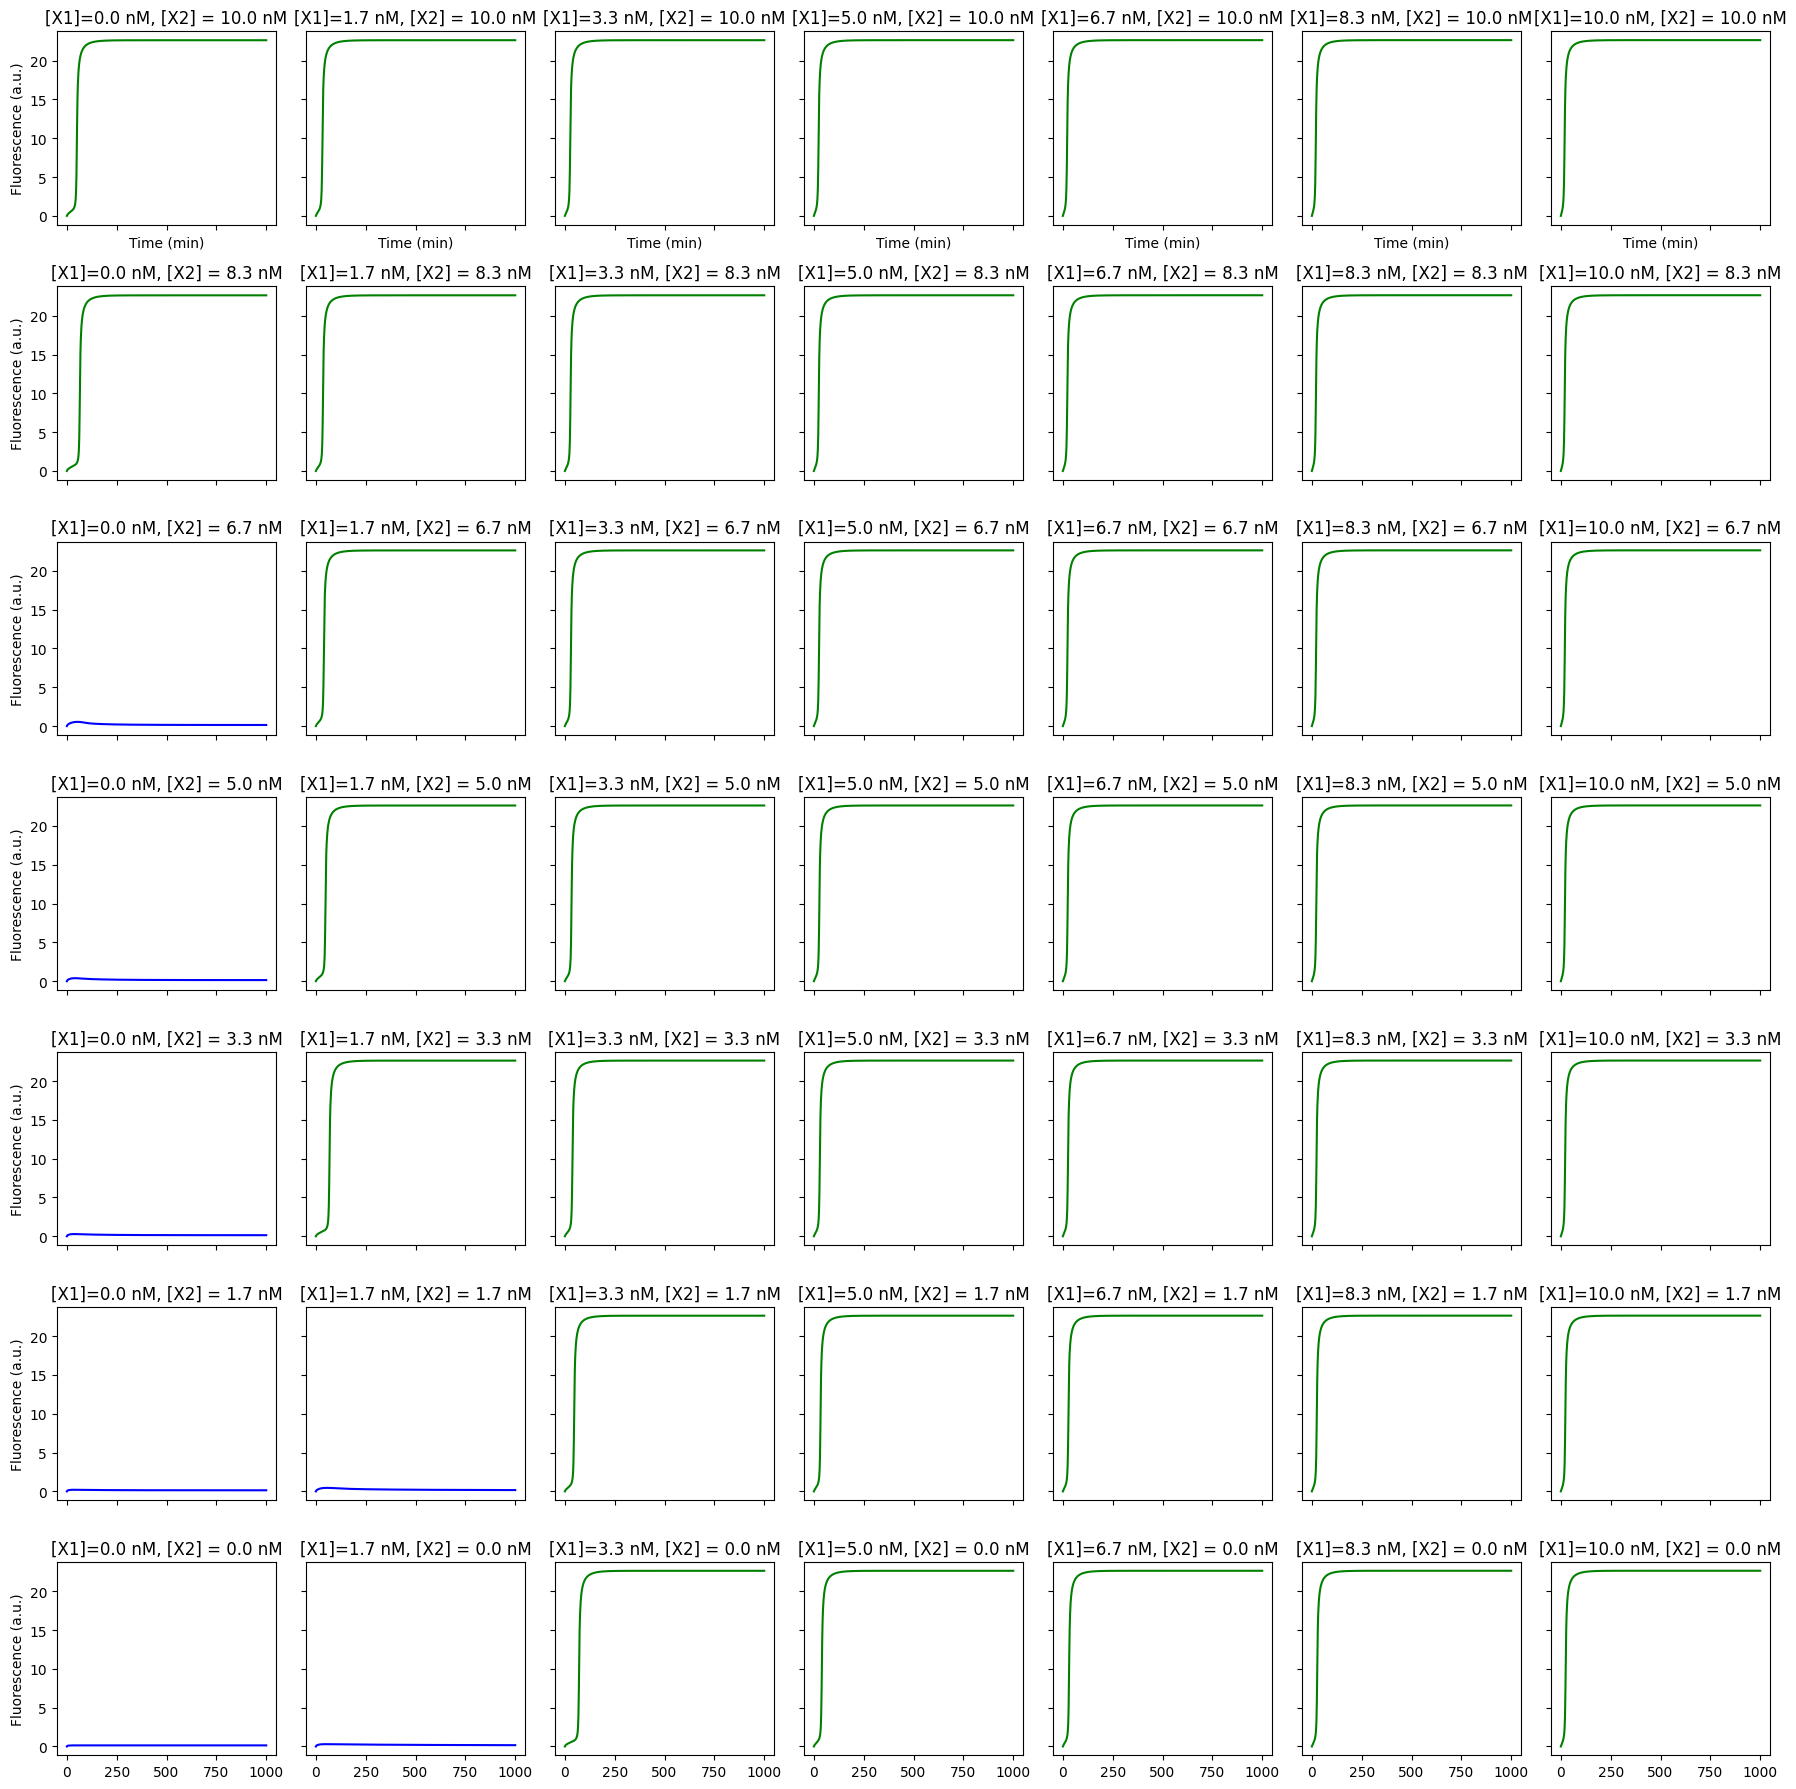

In [ ]:
t= np.linspace(0, 1000, 1001) #1000 minutes

X_concs=[0, 0.167, 0.333, 0.5, 0.667, 0.833, 1]
# X_concs=[0.25,0.5,0.75,1]
# times 10
X_concs=np.multiply(X_concs,10)
print(X_concs)

fig, axes = plt.subplots(len(X_concs), len(X_concs), figsize=(18, 18), sharey=True, sharex=True)

for i, X2_conc in enumerate(X_concs[::-1]):
    
    for j, X1_conc in enumerate(X_concs):
        system = linear_classifier(
            temperature=45,
            pol_conc=30 *4, # Adjustment for Vent, hard to find the right value
            exo_conc=23,
            BsmI_conc=400,
            aT_alpha_conc=30,
            leak=2e-5, # Seems good
            drain_alpha_conc=15, 
            rT_conc=25,
            cT_X1_alpha_conc=0.75,
            cT_X1_f_conc=0.25,
            cT_X2_alpha_conc=0.25, # I suppose there is a mistake in the SI here, as it is not coherent the the schematic of fig. 2
            cT_X2_f_conc=0.75,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )
        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")

        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='blue')
        else:
            axes[i,j].plot(t, fluo, color='green')
        axes[i,j].set_title(f'[X1]={X1_conc:.1f} nM, [X2] = {X2_conc:.1f} nM')

        if i==0:
            axes[i,j].set_xlabel('Time (min)')
        if j==0:
            axes[i,j].set_ylabel('Fluorescence (a.u.)')

plt.tight_layout()
plt.show()




### Fig.2c Positive droplet 3

[ 0.    1.67  3.33  5.    6.67  8.33 10.  ]


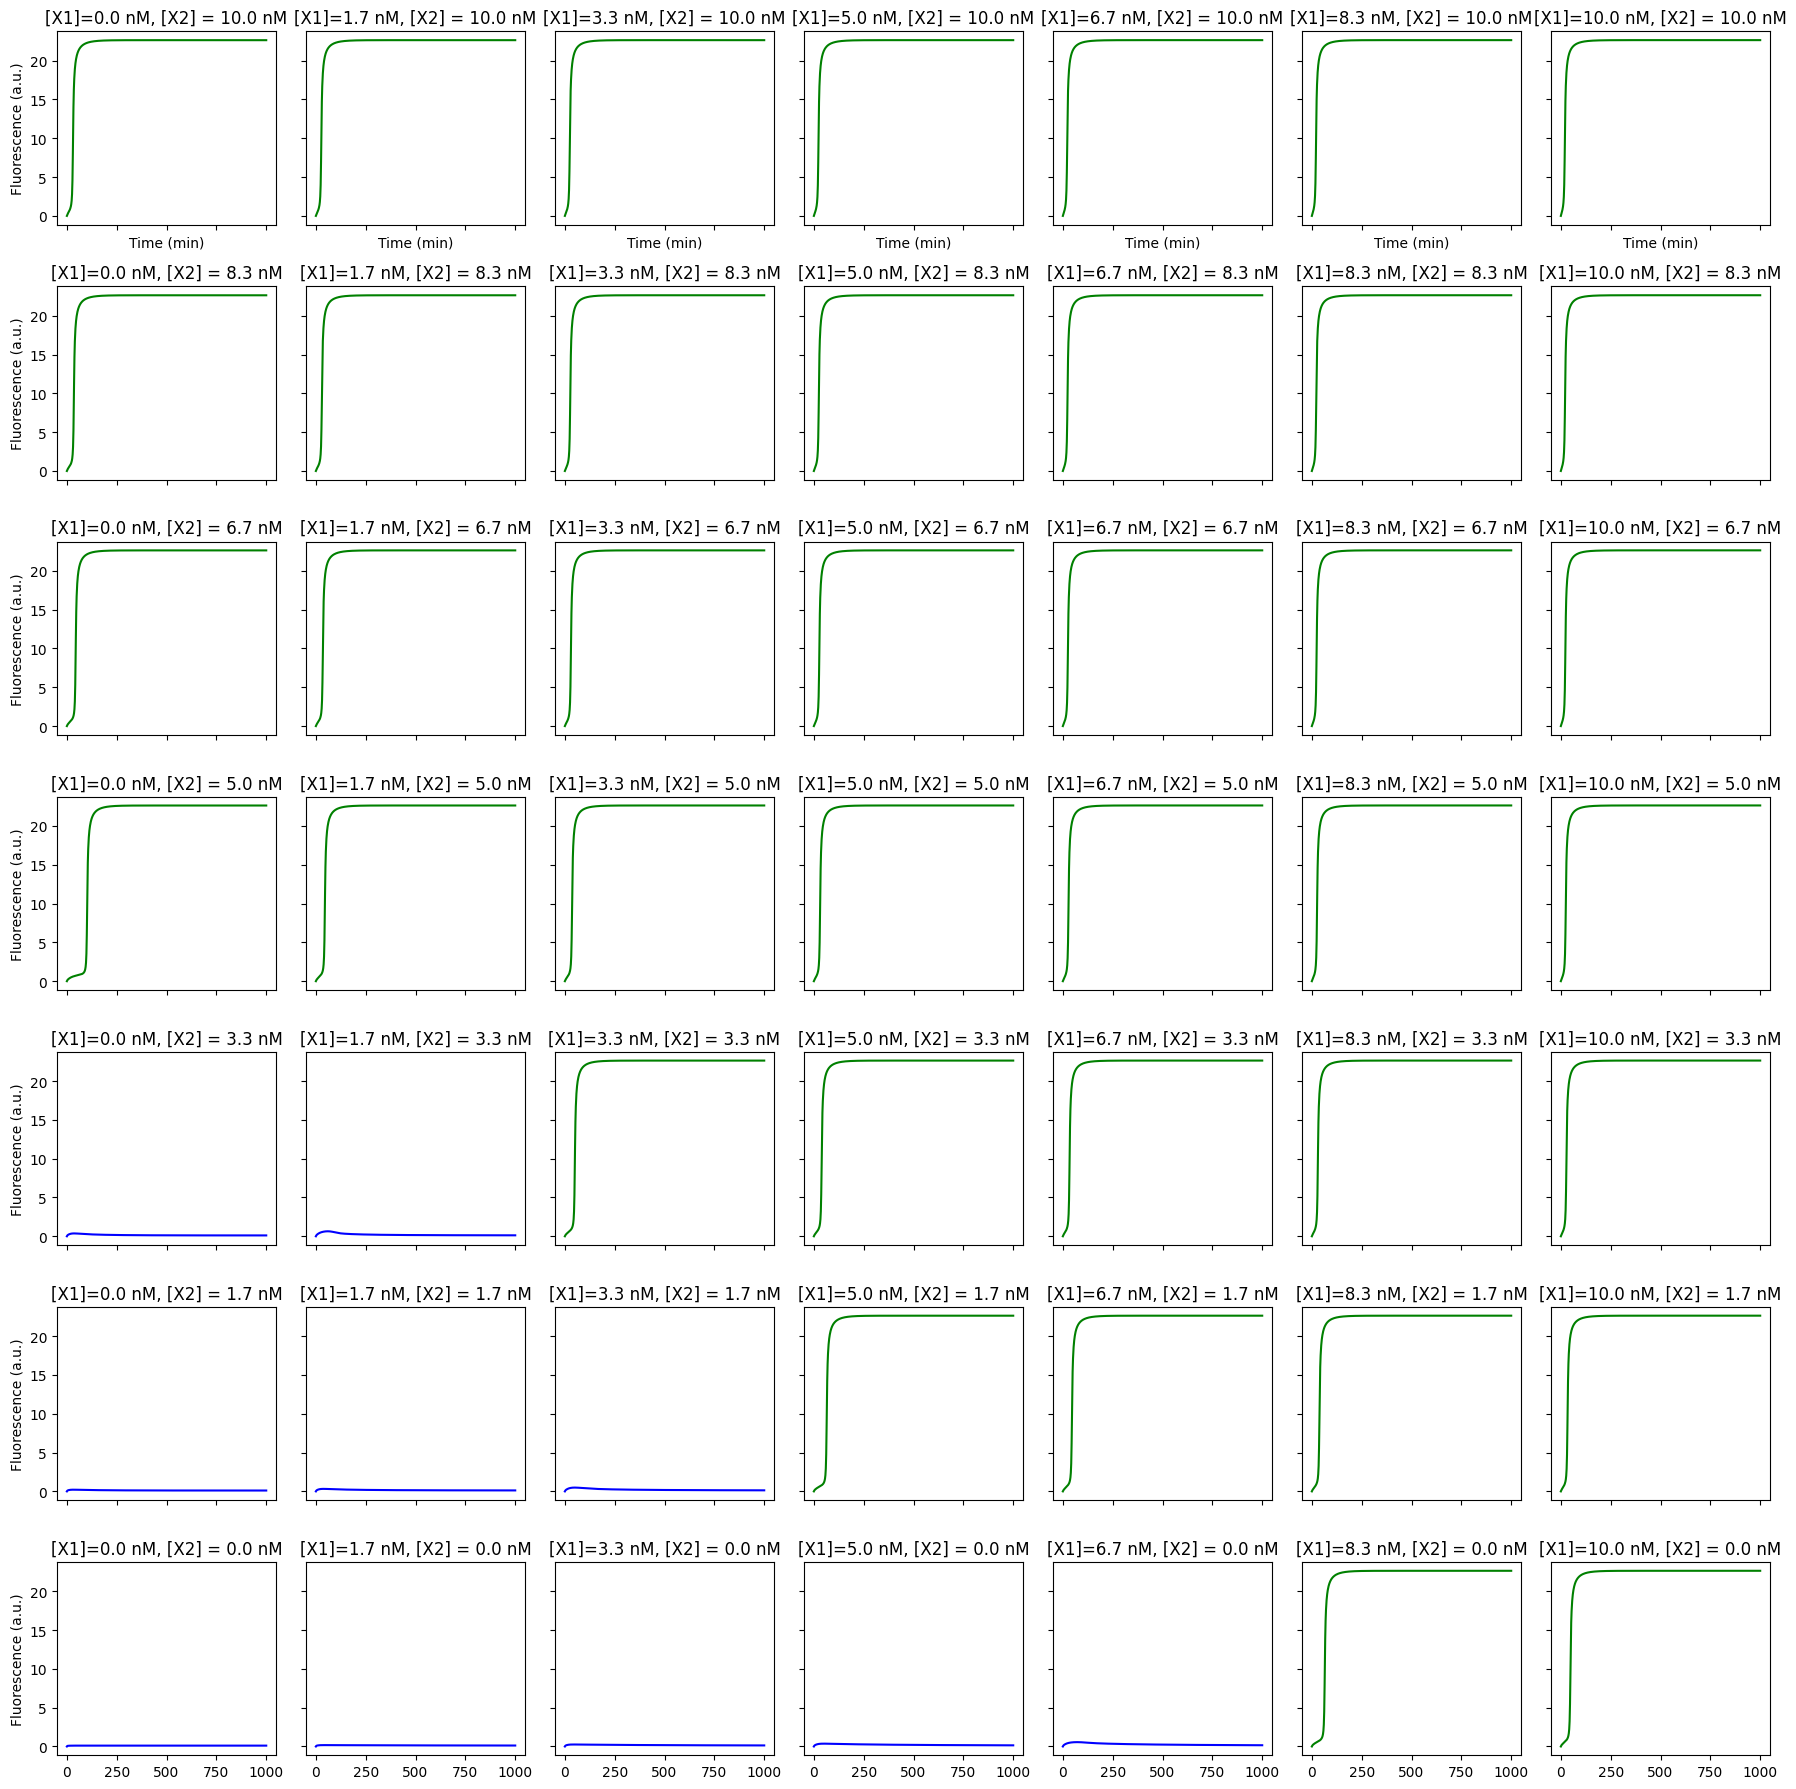

In [ ]:
t= np.linspace(0, 1000, 1001) #1000 minutes

X_concs=[0, 0.167, 0.333, 0.5, 0.667, 0.833, 1]
# X_concs=[0.25,0.5,0.75,1]
# times 10
X_concs=np.multiply(X_concs,10)
print(X_concs)

fig, axes = plt.subplots(len(X_concs), len(X_concs), figsize=(18, 18), sharey=True, sharex=True)

for i, X2_conc in enumerate(X_concs[::-1]):
    
    for j, X1_conc in enumerate(X_concs):
        system = linear_classifier(
            temperature=45,
            pol_conc=30 *4, # Adjustment for Vent, hard to find the right value
            exo_conc=23,
            BsmI_conc=400,
            aT_alpha_conc=30,
            leak=2e-5, # Seems good
            drain_alpha_conc=18, 
            rT_conc=25,
            cT_X1_alpha_conc=0.5,
            cT_X1_f_conc=0.5,
            cT_X2_alpha_conc=0.5,
            cT_X2_f_conc=0.5,
            X1_conc=X1_conc,
            X2_conc=X2_conc,
        )
        y=system.solve_system(t)
        fluo=system.fluorescence_list(y, "rT_alpha")

        if fluo[-1]<5:
            axes[i,j].plot(t, fluo, color='blue')
        else:
            axes[i,j].plot(t, fluo, color='green')
        axes[i,j].set_title(f'[X1]={X1_conc:.1f} nM, [X2] = {X2_conc:.1f} nM')

        if i==0:
            axes[i,j].set_xlabel('Time (min)')
        if j==0:
            axes[i,j].set_ylabel('Fluorescence (a.u.)')

plt.tight_layout()
plt.show()




This is almost the expected behaviour: a shift of the frontier by 2 to the top right corner

The compilation starts to become excessively long...
I need to:
- become smarter for plotting the frontier
- start a project on the code for speeding everything up

### Fig.2d Negative droplet 3

## Majority Voting

### Fig.S12c,f Majority voting

### Fig.S12f Majority voting X3V

### Fig.S12f Majority voting X7V

### Fig.S12f Majority voting X8V

### Fig.S12f Majority voting X3M

### Fig.S12f Majority voting X4M

## Gate Function

### Fig.3 1D gate function

## Space Partitioning

### Fig.4 and Ext. Data Fig.8

### Ext. Data Fig.4

### Ext. Data Fig.6a

### Ext. Data Fig.6b

### Ext. Data Fig.6d,e

### Ext. Data Fig.6f

### Ext. Data Fig.7